# 딥러닝심화 과제 1 - RNN 실습 보고서

### LSTM 모델 구현 및 한글 데이터셋 기반 성능 비교 분석
#### 컴퓨터공학부 인공지능공학과 20231049 정우제
<hr>

## 목차
<hr>

0. [필요한 라이브러리 불러오기](#0-필요한-라이브러리-불러오기)
1. [데이터셋 구축](#1-데이터셋-구축)
2. [LSTM 모델 구현](#2-LSTM-모델-구현)
3. [학습 및 시험](#3-학습-및-시험)
4. [실험 결과 및 분석](#4-실험-결과-및-분석)
5. [분석 및 결론](#5-분석-및-결론)


## 0. 필요한 라이브러리 불러오기
<hr>

In [1]:
# 패키지 불러오기
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## 1. 데이터셋 구축
<hr>

#### 1.1 어절 단위 데이터셋
* 첫 번째 데이터셋은 의미를 가지는 최소 단위인 '천', '백', '십' 을 기준으로 공백을 두어 분리한 형태임.
* ex. 숫자 4720은 사천 칠백 이십으로 변한됨.

#### 1.2 음절 단위 데이터셋
* 두 번째 데이터셋은 한글 텍스트를 구성하는 모든 음절을 하나씩 분리한 형태임.
* * ex. 숫자 4720은 사 천 칠 백 이 십으로 변한됨.

In [2]:
# 어절 단위 데이터셋 경로
train_unit_path = os.path.join('./train_unit.txt')
valid_unit_path = os.path.join('./valid_unit.txt')

In [3]:
# 음절 단위 데이터셋 경로
train_char_path = os.path.join('./train_char.txt')
valid_char_path = os.path.join('./valid_char.txt')

In [4]:
# 어절 단위 데이터셋으로 학습 데이터 만들기 (','로 구분)

train_unit_txt = ' , '.join(o.strip() for o in open(train_unit_path).readlines())
valid_unit_txt = ' , '.join(o.strip() for o in open(valid_unit_path).readlines())
print(train_unit_txt)

일 , 이 , 삼 , 사 , 오 , 육 , 칠 , 팔 , 구 , 십 , 십 일 , 십 이 , 십 삼 , 십 사 , 십 오 , 십 육 , 십 칠 , 십 팔 , 십 구 , 이십 , 이십 일 , 이십 이 , 이십 삼 , 이십 사 , 이십 오 , 이십 육 , 이십 칠 , 이십 팔 , 이십 구 , 삼십 , 삼십 일 , 삼십 이 , 삼십 삼 , 삼십 사 , 삼십 오 , 삼십 육 , 삼십 칠 , 삼십 팔 , 삼십 구 , 사십 , 사십 일 , 사십 이 , 사십 삼 , 사십 사 , 사십 오 , 사십 육 , 사십 칠 , 사십 팔 , 사십 구 , 오십 , 오십 일 , 오십 이 , 오십 삼 , 오십 사 , 오십 오 , 오십 육 , 오십 칠 , 오십 팔 , 오십 구 , 육십 , 육십 일 , 육십 이 , 육십 삼 , 육십 사 , 육십 오 , 육십 육 , 육십 칠 , 육십 팔 , 육십 구 , 칠십 , 칠십 일 , 칠십 이 , 칠십 삼 , 칠십 사 , 칠십 오 , 칠십 육 , 칠십 칠 , 칠십 팔 , 칠십 구 , 팔십 , 팔십 일 , 팔십 이 , 팔십 삼 , 팔십 사 , 팔십 오 , 팔십 육 , 팔십 칠 , 팔십 팔 , 팔십 구 , 구십 , 구십 일 , 구십 이 , 구십 삼 , 구십 사 , 구십 오 , 구십 육 , 구십 칠 , 구십 팔 , 구십 구 , 백 , 백 일 , 백 이 , 백 삼 , 백 사 , 백 오 , 백 육 , 백 칠 , 백 팔 , 백 구 , 백 십 , 백 십 일 , 백 십 이 , 백 십 삼 , 백 십 사 , 백 십 오 , 백 십 육 , 백 십 칠 , 백 십 팔 , 백 십 구 , 백 이십 , 백 이십 일 , 백 이십 이 , 백 이십 삼 , 백 이십 사 , 백 이십 오 , 백 이십 육 , 백 이십 칠 , 백 이십 팔 , 백 이십 구 , 백 삼십 , 백 삼십 일 , 백 삼십 이 , 백 삼십 삼 , 백 삼십 사 , 백 삼십 오 , 백 삼십 육 , 백 삼십 칠 , 백 삼십 팔 , 백 삼십 구 , 백 사십 , 백 사십 일 , 백 사십 이 , 백 사십 삼 , 백 사십 사 , 백 사십 오 

In [5]:
# 음절 단위 데이터셋으로 학습 데이터 만들기 (','로 구분)

train_char_txt = ' , '.join(o.strip() for o in open(train_char_path).readlines())
valid_char_txt = ' , '.join(o.strip() for o in open(valid_char_path).readlines())
print(train_char_txt)

일 , 이 , 삼 , 사 , 오 , 육 , 칠 , 팔 , 구 , 십 , 십 일 , 십 이 , 십 삼 , 십 사 , 십 오 , 십 육 , 십 칠 , 십 팔 , 십 구 , 이 십 , 이 십 일 , 이 십 이 , 이 십 삼 , 이 십 사 , 이 십 오 , 이 십 육 , 이 십 칠 , 이 십 팔 , 이 십 구 , 삼 십 , 삼 십 일 , 삼 십 이 , 삼 십 삼 , 삼 십 사 , 삼 십 오 , 삼 십 육 , 삼 십 칠 , 삼 십 팔 , 삼 십 구 , 사 십 , 사 십 일 , 사 십 이 , 사 십 삼 , 사 십 사 , 사 십 오 , 사 십 육 , 사 십 칠 , 사 십 팔 , 사 십 구 , 오 십 , 오 십 일 , 오 십 이 , 오 십 삼 , 오 십 사 , 오 십 오 , 오 십 육 , 오 십 칠 , 오 십 팔 , 오 십 구 , 육 십 , 육 십 일 , 육 십 이 , 육 십 삼 , 육 십 사 , 육 십 오 , 육 십 육 , 육 십 칠 , 육 십 팔 , 육 십 구 , 칠 십 , 칠 십 일 , 칠 십 이 , 칠 십 삼 , 칠 십 사 , 칠 십 오 , 칠 십 육 , 칠 십 칠 , 칠 십 팔 , 칠 십 구 , 팔 십 , 팔 십 일 , 팔 십 이 , 팔 십 삼 , 팔 십 사 , 팔 십 오 , 팔 십 육 , 팔 십 칠 , 팔 십 팔 , 팔 십 구 , 구 십 , 구 십 일 , 구 십 이 , 구 십 삼 , 구 십 사 , 구 십 오 , 구 십 육 , 구 십 칠 , 구 십 팔 , 구 십 구 , 백 , 백 일 , 백 이 , 백 삼 , 백 사 , 백 오 , 백 육 , 백 칠 , 백 팔 , 백 구 , 백 십 , 백 십 일 , 백 십 이 , 백 십 삼 , 백 십 사 , 백 십 오 , 백 십 육 , 백 십 칠 , 백 십 팔 , 백 십 구 , 백 이 십 , 백 이 십 일 , 백 이 십 이 , 백 이 십 삼 , 백 이 십 사 , 백 이 십 오 , 백 이 십 육 , 백 이 십 칠 , 백 이 십 팔 , 백 이 십 구 , 백 삼 십 , 백 삼 십 일 , 백 삼 십 이 , 백 삼 십 삼 , 백 삼 십 사 , 

* 두 데이터셋의 가장 큰 차이점은 전체 시퀀스를 구성하는 토큰의 총 개수, 전체적인 길이에 있음.
* 밑에서 보게되면 어절 단위는 3.6만개, 음절 단위는 5.5만 개의 토큰으로 구성되어 상당한 길이 차이를 보임.

In [6]:
# 어절 단위 단어 쪼개기

train_unit_list = train_unit_txt.split(' ')
valid_unit_list = valid_unit_txt.split(' ')
print(len(train_unit_list))
print(train_unit_list)

36598
['일', ',', '이', ',', '삼', ',', '사', ',', '오', ',', '육', ',', '칠', ',', '팔', ',', '구', ',', '십', ',', '십', '일', ',', '십', '이', ',', '십', '삼', ',', '십', '사', ',', '십', '오', ',', '십', '육', ',', '십', '칠', ',', '십', '팔', ',', '십', '구', ',', '이십', ',', '이십', '일', ',', '이십', '이', ',', '이십', '삼', ',', '이십', '사', ',', '이십', '오', ',', '이십', '육', ',', '이십', '칠', ',', '이십', '팔', ',', '이십', '구', ',', '삼십', ',', '삼십', '일', ',', '삼십', '이', ',', '삼십', '삼', ',', '삼십', '사', ',', '삼십', '오', ',', '삼십', '육', ',', '삼십', '칠', ',', '삼십', '팔', ',', '삼십', '구', ',', '사십', ',', '사십', '일', ',', '사십', '이', ',', '사십', '삼', ',', '사십', '사', ',', '사십', '오', ',', '사십', '육', ',', '사십', '칠', ',', '사십', '팔', ',', '사십', '구', ',', '오십', ',', '오십', '일', ',', '오십', '이', ',', '오십', '삼', ',', '오십', '사', ',', '오십', '오', ',', '오십', '육', ',', '오십', '칠', ',', '오십', '팔', ',', '오십', '구', ',', '육십', ',', '육십', '일', ',', '육십', '이', ',', '육십', '삼', ',', '육십', '사', ',', '육십', '오', ',', '육십', '육', ',', '육십', '칠', ',', '육십', '팔', ',',

In [7]:
# 음절 단위 단어 쪼개기

train_char_list = train_char_txt.split(' ')
valid_char_list = valid_char_txt.split(' ')
print(len(train_char_list))
print(train_char_list)

55398
['일', ',', '이', ',', '삼', ',', '사', ',', '오', ',', '육', ',', '칠', ',', '팔', ',', '구', ',', '십', ',', '십', '일', ',', '십', '이', ',', '십', '삼', ',', '십', '사', ',', '십', '오', ',', '십', '육', ',', '십', '칠', ',', '십', '팔', ',', '십', '구', ',', '이', '십', ',', '이', '십', '일', ',', '이', '십', '이', ',', '이', '십', '삼', ',', '이', '십', '사', ',', '이', '십', '오', ',', '이', '십', '육', ',', '이', '십', '칠', ',', '이', '십', '팔', ',', '이', '십', '구', ',', '삼', '십', ',', '삼', '십', '일', ',', '삼', '십', '이', ',', '삼', '십', '삼', ',', '삼', '십', '사', ',', '삼', '십', '오', ',', '삼', '십', '육', ',', '삼', '십', '칠', ',', '삼', '십', '팔', ',', '삼', '십', '구', ',', '사', '십', ',', '사', '십', '일', ',', '사', '십', '이', ',', '사', '십', '삼', ',', '사', '십', '사', ',', '사', '십', '오', ',', '사', '십', '육', ',', '사', '십', '칠', ',', '사', '십', '팔', ',', '사', '십', '구', ',', '오', '십', ',', '오', '십', '일', ',', '오', '십', '이', ',', '오', '십', '삼', ',', '오', '십', '사', ',', '오', '십', '오', ',', '오', '십', '육', ',', '오', '십', '칠', ',', '오', '십', '팔', ','

In [8]:
# 어절 단어장 만들기

train_unit_set = set(train_unit_txt.split(' '))
valid_unit_set = set(valid_unit_txt.split(' '))
print(train_unit_set)

{'사', '삼천', '오십', '팔', '십', '이백', '팔십', '삼', '백', '사십', '삼백', '일', '칠십', '구백', '오백', '천', '육', '이십', '삼십', '오천', '구', '구십', '오', '팔백', '칠천', '이', '육십', ',', '이천', '사천', '육천', '육백', '칠백', '사백', '칠'}


In [9]:
# 음절 단어장 만들기

train_char_set = set(train_char_txt.split(' '))
valid_char_set = set(valid_char_txt.split(' '))
print(train_char_set)

{'사', '이', '팔', '십', ',', '일', '구', '백', '삼', '천', '육', '오', '칠'}


* 전체 토큰의 총 개수뿐만 아니라, 모델이 학습해야 할 고유 토큰의 종류와 수, 즉 단어 사전의 크기에서도 두 데이터셋은 차이를 보임.
  * 어절 단위 데이터셋은 모든 단위(일~구,십,이십,삽백...)를 각각의 고유한 토큰으로 포함해서 단어 사전의 크기가 큼.
  * 음절 단위 데이터셋은 기본적인 음절들로(일~구,십,백,천...)으로 구성되어 단어 사전의 크기가 작음.

In [10]:
# 어절 사전 만들기
vocab_unit = train_unit_set.union(valid_unit_set)
print(len(vocab_unit))

37


In [11]:
# 음절 사전 만들기
vocab_char = train_char_set.union(valid_char_set)
print(len(vocab_char))

13


In [12]:
# 어절 단위 연결 딕셔너리 생성
# 숫자 : 단어 연결 딕셔너리 생성

int2string_unit = dict(enumerate(vocab_unit))
print(int2string_unit)

# 단어 : 숫자 연결 딕셔너리 생성

string2int_unit = {string : ind for ind, string in int2string_unit.items()}
print(string2int_unit)

{0: '사', 1: '삼천', 2: '오십', 3: '팔', 4: '십', 5: '이백', 6: '팔십', 7: '삼', 8: '백', 9: '사십', 10: '삼백', 11: '일', 12: '칠십', 13: '구백', 14: '오백', 15: '천', 16: '육', 17: '이십', 18: '삼십', 19: '오천', 20: '구', 21: '구천', 22: '구십', 23: '오', 24: '팔백', 25: '칠천', 26: '이', 27: '육십', 28: ',', 29: '이천', 30: '사천', 31: '육천', 32: '팔천', 33: '육백', 34: '칠백', 35: '사백', 36: '칠'}
{'사': 0, '삼천': 1, '오십': 2, '팔': 3, '십': 4, '이백': 5, '팔십': 6, '삼': 7, '백': 8, '사십': 9, '삼백': 10, '일': 11, '칠십': 12, '구백': 13, '오백': 14, '천': 15, '육': 16, '이십': 17, '삼십': 18, '오천': 19, '구': 20, '구천': 21, '구십': 22, '오': 23, '팔백': 24, '칠천': 25, '이': 26, '육십': 27, ',': 28, '이천': 29, '사천': 30, '육천': 31, '팔천': 32, '육백': 33, '칠백': 34, '사백': 35, '칠': 36}


In [13]:
# 음절 단위 연결 딕셔너리 생성
# 숫자 : 단어 연결 딕셔너리 생성

int2string_char = dict(enumerate(vocab_char))
print(int2string_char)

# 단어 : 숫자 연결 딕셔너리 생성

string2int_char = {string : ind for ind, string in int2string_char.items()}
print(string2int_char)

{0: '사', 1: '팔', 2: '십', 3: '구', 4: '백', 5: '삼', 6: '오', 7: '이', 8: ',', 9: '일', 10: '천', 11: '육', 12: '칠'}
{'사': 0, '팔': 1, '십': 2, '구': 3, '백': 4, '삼': 5, '오': 6, '이': 7, ',': 8, '일': 9, '천': 10, '육': 11, '칠': 12}


In [14]:
# 학습 장치 설정

is_cuda = torch.cuda.is_available()
is_mps = torch.backends.mps.is_available()
device = torch.device('cuda' if is_cuda else 'mps' if is_mps else 'cpu')
print(device)

cpu


* 기존 데이터로더 코드에다 string2int를 추가해 두 가지 데이터셋 처리하도록 수정함.

In [15]:
# 학습 데이터(입력, 출력) 쌍 만들기

class DataLoaderModel():
    def __init__(self, train_data, string2int, index=0, tbptt_length=10, batch_size=64):  
        self.train_data = train_data
        self.string2int = string2int # 전달받은 사전을 인스턴스 변수로 저장
        self.index = index
        self.tbptt_length = tbptt_length # the number of words in a sequence
        self.batch_size = batch_size      # batch size

    def __iter__(self):
        return self

    def __next__(self):
        input_seq = []  # 학습용 입력 데이터
        output_seq = [] # 학습용 출력 데이터

        if self.index + (self.tbptt_length * self.batch_size) + 1 > len(self.train_data): # 데이터 소진
            raise StopIteration
        
        index = self.index
        
        # make a batch
        for _ in range(self.batch_size):
            input_line = []
            output_line = []
            
            # make a line
            for _ in range(self.tbptt_length):
                input_line.append(self.train_data[index])
                # output line is 1 step ahead of input line
                output_line.append(self.train_data[index + 1])
                index += 1
            
            input_seq.append(input_line)
            output_seq.append(output_line)

        self.index=index
        
        for i in range(len(input_seq)):
            # need to map string to int
            # 클래스 생성 시 전달받은 self.string2int 사전을 사용하여 변환
            input_seq[i] = [self.string2int[string] for string in input_seq[i]]
            output_seq[i] = [self.string2int[string] for string in output_seq[i]]

        # convert arrays into tensors and place on gpu
        input_seq = torch.tensor(input_seq, dtype=torch.long).to(device)
        output_seq = torch.tensor(output_seq, dtype=torch.long).to(device)
        
        return input_seq, output_seq

In [16]:
# 어절 단위 학습 데이터 (입력 , 출력) 쌍 확인
data_unit = DataLoaderModel(train_unit_list, string2int_unit, tbptt_length=10)
x_unit, y_unit = data_unit.__next__()
print("--- 어절 단위 ---")
print(x_unit.shape, y_unit.shape)
print(x_unit[0], y_unit[0])

--- 어절 단위 ---
torch.Size([64, 10]) torch.Size([64, 10])
tensor([11, 28, 26, 28,  7, 28,  0, 28, 23, 28]) tensor([28, 26, 28,  7, 28,  0, 28, 23, 28, 16])


In [17]:
# 음절 단위 학습 데이터 (입력 , 출력) 쌍 확인
data_char = DataLoaderModel(train_char_list, string2int_char, tbptt_length=10)
x_char, y_char = data_char.__next__()
print("--- 음절 단위 ---")
print(x_char.shape, y_char.shape)
print(x_char[0], y_char[0])

--- 음절 단위 ---
torch.Size([64, 10]) torch.Size([64, 10])
tensor([9, 8, 7, 8, 5, 8, 0, 8, 6, 8]) tensor([ 8,  7,  8,  5,  8,  0,  8,  6,  8, 11])


## 2. LSTM 모델 구현
<hr>

### 2.1  LSTMModel의 직접 구현 모델 

In [18]:
class LSTMCell(nn.Module):
    
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        
        # 망각 게이트 가중치
        self.W_xf = nn.Embedding(input_size, hidden_size)
        self.W_hf = nn.Linear(hidden_size, hidden_size)
        
        # 입력 게이트 가중치
        self.W_xi = nn.Embedding(input_size, hidden_size)
        self.W_hi = nn.Linear(hidden_size, hidden_size)
        
        # 출력 게이트 가중치
        self.W_xo = nn.Embedding(input_size, hidden_size)
        self.W_ho = nn.Linear(hidden_size, hidden_size)
        
        # 셀 상태 후 가중치
        self.W_xc = nn.Embedding(input_size, hidden_size)
        self.W_hc = nn.Linear(hidden_size, hidden_size)
        
        self.reset_parameters()

    def reset_parameters(self):
        std = 1.0 / np.sqrt(self.hidden_size)
        for w in self.parameters():
            w.data.uniform_(-std, std)
    
    def forward(self, x, states):
        h, c = states
        
        # 망각 게이트: 이전 셀 상태(c)에서 무엇을 잊을지 결정
        forget_gate = torch.sigmoid(self.W_xf(x) + self.W_hf(h))
        
        # 입력 게이트: 새로운 정보(x, h) 중 무엇을 셀 상태에 저장할지 결정
        input_gate = torch.sigmoid(self.W_xi(x) + self.W_hi(h))
        
        # 출력 게이트: 현재 셀 상태에서 무엇을 밖으로 보낼지 결정
        output_gate = torch.sigmoid(self.W_xo(x) + self.W_ho(h))
        
        # 셀 상태 후보: 새로 기억할 후보 정보를 생성
        candidate_c = torch.tanh(self.W_xc(x) + self.W_hc(h))
        
        # 셀 상태 업데이트: 잊을 건 잊고(forget_gate * c), 새 정보는 더함(input_gate * candidate_c)
        c_next = forget_gate * c + input_gate * candidate_c
        
        # 은닉 상태 업데이트: 최종적으로 밖으로 보낼 출력을 계산
        h_next = output_gate * torch.tanh(c_next)
        
        return h_next, c_next

In [19]:
class My_LSTMModel(nn.Module):
    
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.rnn = LSTMCell(self.input_dim, self.hidden_dim)
        self.W_hq = nn.Linear(self.hidden_dim, self.output_dim)
        self.bn   = nn.BatchNorm1d(num_features=self.hidden_dim)
        
    def forward(self, x):
        h = torch.zeros(x.shape[0], self.hidden_dim).to(x.device) # 초기 은닉 상태
        c = torch.zeros(x.shape[0], self.hidden_dim).to(x.device) # 초기 셀 상태
        
        res = []
        
        for i in range(x.shape[1]): # 각 TBPTT 시간 단계 반복: 각 단어에 대해
            h, c = self.rnn(x[:, i], (h, c))
            res.append(self.W_hq(self.bn(h))) # 출력 
            
        return torch.stack(res, dim=1)

### 2.2 PyTorch의 nn.LSTM를 이용한 구현 모델

In [20]:
nh = 64

class LSTMModel(nn.Module):
    
    def __init__(self, vocab_size):
        super().__init__()
        self.W_xh = nn.Embedding(vocab_size, nh) 
        self.rnn = nn.LSTM(input_size=nh, hidden_size=nh, num_layers=2, batch_first=True) # Stacked LSTM
        self.W_hq = nn.Linear(nh, vocab_size)
        self.bn   = nn.BatchNorm1d(num_features=nh)
        
    def forward(self, x):
        # LSTM은 은닉 상태와 셀 상태, 두 개의 상태를 가짐
        h_0 = torch.zeros(2, x.shape[0], nh).to(device) # 2 stacked 은닉계층 (2, N, Hout)
        c_0 = torch.zeros(2, x.shape[0], nh).to(device) # 2 stacked 셀 상태 (2, N, Hout)

        # 입력:임베딩된 배치 입력, (초기 은닉 상태, 초기 셀 상태) 값 입력 -> 출력, (최종 은닉 상태, 최종 셀 상태) 값 출력
        res, (h_n, c_n) = self.rnn(self.W_xh(x), (h_0, c_0))
        
        # 계산 그래프 분리
        self.hidden_state = h_n.detach()
        self.cell_state   = c_n.detach()

        res    = res.permute(0, 2, 1) # res: (N, L, Hout)
        res    = self.bn(res)         # (N, Hout, L) 채널차원에 대해 정규화
        return self.W_hq(res.permute(0, 2, 1))

## 3. 학습 및 시험
<hr>

## 3.1 LSTMModel의 직접 구현 모델 학습 및 시험

#### 3.1.1 LSTMModel 직접 구현 모델을 통한 어절 단위 학습 및 시험

In [21]:
nx = nq = len(vocab_unit)
model1_unit = My_LSTMModel(nx, nh, nq).to(device)
model1_unit.train()

My_LSTMModel(
  (rnn): LSTMCell(
    (W_xf): Embedding(37, 64)
    (W_hf): Linear(in_features=64, out_features=64, bias=True)
    (W_xi): Embedding(37, 64)
    (W_hi): Linear(in_features=64, out_features=64, bias=True)
    (W_xo): Embedding(37, 64)
    (W_ho): Linear(in_features=64, out_features=64, bias=True)
    (W_xc): Embedding(37, 64)
    (W_hc): Linear(in_features=64, out_features=64, bias=True)
  )
  (W_hq): Linear(in_features=64, out_features=37, bias=True)
  (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)

In [22]:
data1_unit = DataLoaderModel(train_unit_list, string2int_unit, tbptt_length=10)
x, y = data1_unit.__next__()
y_hat = model1_unit(x)
print(y.size(), y_hat.size())

torch.Size([64, 10]) torch.Size([64, 10, 37])


In [23]:
# 손실 함수 및 최적화 함수 구현
lr = 1e-3

# 어절 단위 모델을 위한 옵티마이저
optimizer1_unit = torch.optim.Adam(model1_unit.parameters(), lr=lr)


def loss_func(output, target):
    return F.cross_entropy(output.permute(0,2,1), target)  # 클래스 위치 변경

In [24]:
#평가 지표 저장 공간 준비
losses_1=[]
accuracy_1=[]

#학습
batch_size = 64
n_epochs   = 50

for epoch in range(1, n_epochs+1):
    # 여기서 어절단위 파라미터들로 넘겨줌
    data = DataLoaderModel(train_unit_list, string2int_unit, tbptt_length=70, batch_size=batch_size)
    
    for x, y in data:
        y_hat = model1_unit(x)
        loss = loss_func(y_hat, y)
        loss.backward()
        optimizer1_unit.step()
        optimizer1_unit.zero_grad()
        
        predicted = torch.argmax(y_hat[:,-1,:], dim=1) # max_indices를 예측값으로 저장
        
        correct = (predicted==y[:,-1]).sum().item()
        
        losses_1.append(loss.item())
        accuracy_1.append(correct / batch_size)
        
    print('Epoch: {:2}/{}  |  Loss: {:.4f}  |  Accuracy: {:.4f}'.format(epoch, n_epochs, np.mean(losses_1[-3:]), np.mean(accuracy_1[-3:])))

Epoch:  1/50  |  Loss: 3.6869  |  Accuracy: 0.0000
Epoch:  2/50  |  Loss: 3.3874  |  Accuracy: 0.0625
Epoch:  3/50  |  Loss: 3.0993  |  Accuracy: 0.1719
Epoch:  4/50  |  Loss: 2.8164  |  Accuracy: 0.2865
Epoch:  5/50  |  Loss: 2.5483  |  Accuracy: 0.3333
Epoch:  6/50  |  Loss: 2.3149  |  Accuracy: 0.3958
Epoch:  7/50  |  Loss: 2.1148  |  Accuracy: 0.4896
Epoch:  8/50  |  Loss: 1.9460  |  Accuracy: 0.5729
Epoch:  9/50  |  Loss: 1.8107  |  Accuracy: 0.5990
Epoch: 10/50  |  Loss: 1.6854  |  Accuracy: 0.6354
Epoch: 11/50  |  Loss: 1.5721  |  Accuracy: 0.6458
Epoch: 12/50  |  Loss: 1.4687  |  Accuracy: 0.7083
Epoch: 13/50  |  Loss: 1.3725  |  Accuracy: 0.7604
Epoch: 14/50  |  Loss: 1.2852  |  Accuracy: 0.7812
Epoch: 15/50  |  Loss: 1.2038  |  Accuracy: 0.8073
Epoch: 16/50  |  Loss: 1.1280  |  Accuracy: 0.8177
Epoch: 17/50  |  Loss: 1.0599  |  Accuracy: 0.8281
Epoch: 18/50  |  Loss: 0.9972  |  Accuracy: 0.8490
Epoch: 19/50  |  Loss: 0.9386  |  Accuracy: 0.8542
Epoch: 20/50  |  Loss: 0.8859  

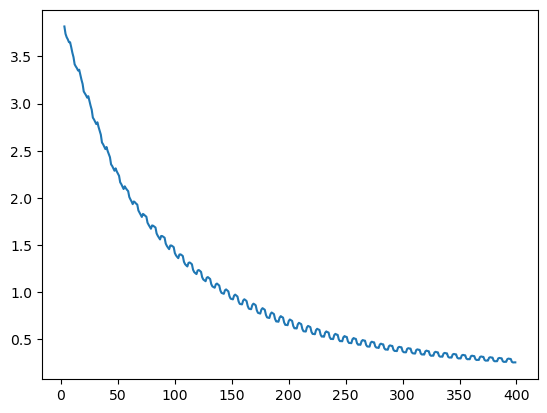

In [25]:
# 학습 결과 시각화: 손실

import matplotlib.pyplot as plt
import pandas as pd

plt.plot(pd.Series(losses_1).rolling(4).mean())

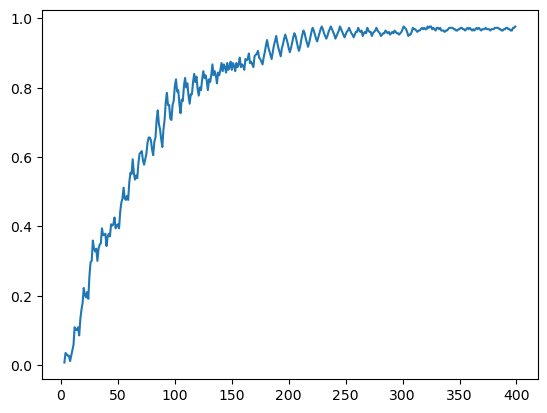

In [26]:
# 학습 결과 시각화: 정확도

plt.plot(pd.Series(accuracy_1).rolling(4).mean())

In [27]:
start = np.random.randint(0, len(valid_unit_list)-150)
seed_list = valid_unit_list[start:start+20]

current_string = [string for string in seed_list]
print(current_string)

['삼십', '팔', ',', '구천', '삼백', '삼십', '구', ',', '구천', '삼백', '사십', ',', '구천', '삼백', '사십', '일', ',', '구천', '삼백', '사십']


In [28]:
current_string = [string2int_unit[string] for string in seed_list]
print(current_string)

[18, 3, 28, 21, 10, 18, 20, 28, 21, 10, 9, 28, 21, 10, 9, 11, 28, 21, 10, 9]


In [29]:
model1_unit.eval()

for i in range(20):
    x = torch.tensor(current_string, dtype=torch.long).to(device).reshape(1,-1)
    output = model1_unit(x)
    predicted = torch.argmax(output[:,-1,:], dim=1)
    current_string.append(predicted.item())
    
print(' '.join(seed_list))

삼십 팔 , 구천 삼백 삼십 구 , 구천 삼백 사십 , 구천 삼백 사십 일 , 구천 삼백 사십


In [30]:
print(' '.join(int2string_unit[x] for x in current_string))

삼십 팔 , 구천 삼백 삼십 구 , 구천 삼백 사십 , 구천 삼백 사십 일 , 구천 삼백 사십 오 , 칠천 삼백 삼십 일 , 칠천 삼백 삼십 이 , 칠천 삼백 삼십 삼 , 칠천 삼백 삼십


#### 3.1.2 LSTMMOdel 직접 구현 모델을 통한 음절 단위 학습 및 시험

In [31]:
nx = nq = len(vocab_char)
model1_char = My_LSTMModel(nx, nh, nq).to(device)
model1_char.train()

My_LSTMModel(
  (rnn): LSTMCell(
    (W_xf): Embedding(13, 64)
    (W_hf): Linear(in_features=64, out_features=64, bias=True)
    (W_xi): Embedding(13, 64)
    (W_hi): Linear(in_features=64, out_features=64, bias=True)
    (W_xo): Embedding(13, 64)
    (W_ho): Linear(in_features=64, out_features=64, bias=True)
    (W_xc): Embedding(13, 64)
    (W_hc): Linear(in_features=64, out_features=64, bias=True)
  )
  (W_hq): Linear(in_features=64, out_features=13, bias=True)
  (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)

In [32]:
data1_char = DataLoaderModel(train_char_list, string2int_char, tbptt_length=10)
x, y = data1_char.__next__()
y_hat = model1_char(x)
print(y.size(), y_hat.size())

torch.Size([64, 10]) torch.Size([64, 10, 13])


In [33]:
# 손실 함수 및 최적화 함수 구현
lr = 1e-3

# 음절 단위 모델을 위한 옵티마이저
optimizer1_char = torch.optim.Adam(model1_char.parameters(), lr=lr)


def loss_func(output, target):
    return F.cross_entropy(output.permute(0,2,1), target)  # 클래스 위치 변경


In [34]:
#평가 지표 저장 공간 준비
losses_2=[]
accuracy_2=[]

#학습
batch_size = 64
n_epochs   = 50

for epoch in range(1, n_epochs+1):
    # 여기서 음절단위 파라미터들로 넘겨줌
    data = DataLoaderModel(train_char_list, string2int_char, tbptt_length=70, batch_size=batch_size)
    
    for x, y in data:
        y_hat = model1_char(x)
        loss = loss_func(y_hat, y)
        loss.backward()
        optimizer1_char.step()
        optimizer1_char.zero_grad()
        
        predicted = torch.argmax(y_hat[:,-1,:], dim=1) # max_indices를 예측값으로 저장
        
        correct = (predicted==y[:,-1]).sum().item()
        
        losses_2.append(loss.item())
        accuracy_2.append(correct / batch_size)
        
    print('Epoch: {:2}/{}  |  Loss: {:.4f}  |  Accuracy: {:.4f}'.format(epoch, n_epochs, np.mean(losses_2[-3:]), np.mean(accuracy_2[-3:])))

Epoch:  1/50  |  Loss: 2.3482  |  Accuracy: 0.2552
Epoch:  2/50  |  Loss: 2.0141  |  Accuracy: 0.4062
Epoch:  3/50  |  Loss: 1.7590  |  Accuracy: 0.4792
Epoch:  4/50  |  Loss: 1.5644  |  Accuracy: 0.4688
Epoch:  5/50  |  Loss: 1.4267  |  Accuracy: 0.4740
Epoch:  6/50  |  Loss: 1.3436  |  Accuracy: 0.4740
Epoch:  7/50  |  Loss: 1.2978  |  Accuracy: 0.4740
Epoch:  8/50  |  Loss: 1.2643  |  Accuracy: 0.4844
Epoch:  9/50  |  Loss: 1.2315  |  Accuracy: 0.5469
Epoch: 10/50  |  Loss: 1.1909  |  Accuracy: 0.5729
Epoch: 11/50  |  Loss: 1.1472  |  Accuracy: 0.6042
Epoch: 12/50  |  Loss: 1.1037  |  Accuracy: 0.6302
Epoch: 13/50  |  Loss: 1.0597  |  Accuracy: 0.6354
Epoch: 14/50  |  Loss: 1.0191  |  Accuracy: 0.6979
Epoch: 15/50  |  Loss: 0.9823  |  Accuracy: 0.6771
Epoch: 16/50  |  Loss: 0.9414  |  Accuracy: 0.7292
Epoch: 17/50  |  Loss: 0.9214  |  Accuracy: 0.7135
Epoch: 18/50  |  Loss: 0.8840  |  Accuracy: 0.7500
Epoch: 19/50  |  Loss: 0.8538  |  Accuracy: 0.7812
Epoch: 20/50  |  Loss: 0.8201  

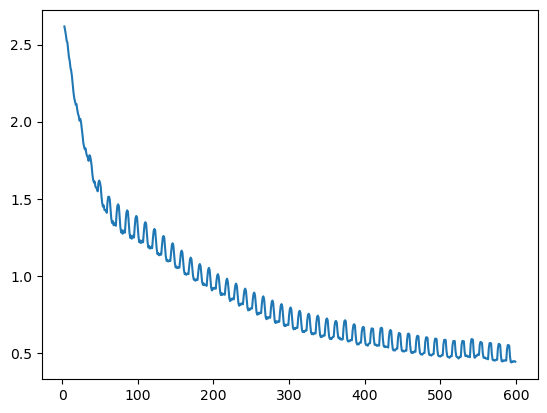

In [35]:
# 학습 결과 시각화: 손실

import matplotlib.pyplot as plt
import pandas as pd

plt.plot(pd.Series(losses_2).rolling(4).mean())

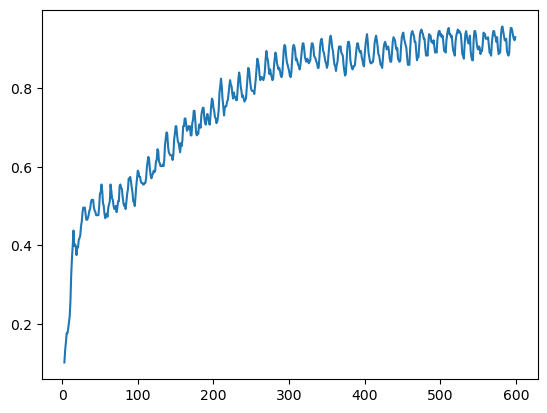

In [36]:
# 학습 결과 시각화: 정확도

plt.plot(pd.Series(accuracy_2).rolling(4).mean())


In [37]:
start = np.random.randint(0, len(valid_char_list)-150)
seed_list = valid_char_list[start:start+20]

current_string = [string for string in seed_list]
print(current_string)

current_string = [string2int_char[string] for string in seed_list]
print(current_string)

['백', '삼', '십', ',', '구', '천', '육', '백', '삼', '십', '일', ',', '구', '천', '육', '백', '삼', '십', '이', ',']
[4, 5, 2, 8, 3, 10, 11, 4, 5, 2, 9, 8, 3, 10, 11, 4, 5, 2, 7, 8]


In [38]:
model1_char.eval()

for i in range(20):
    x = torch.tensor(current_string, dtype=torch.long).to(device).reshape(1,-1)
    output = model1_char(x)
    predicted = torch.argmax(output[:,-1,:], dim=1)
    current_string.append(predicted.item())
    
print(' '.join(seed_list))

백 삼 십 , 구 천 육 백 삼 십 일 , 구 천 육 백 삼 십 이 ,


In [39]:
print(' '.join(int2string_char[x] for x in current_string))

백 삼 십 , 구 천 육 백 삼 십 일 , 구 천 육 백 삼 십 이 , 육 천 사 백 삼 십 육 , 사 천 오 백 삼 십 육 , 사 천 육 백


## 3.2 PyTorch의 nn.LSTM를 이용한 모델 학습 및 시험

#### 3.2.1 PyTorch의 nn.LSTM를 이용한 모델을 통한 어절 단위 학습 및 시험

In [40]:
nx = nq = len(vocab_unit)
model2_unit = LSTMModel(nx).to(device)
model2_unit.train()

LSTMModel(
  (W_xh): Embedding(37, 64)
  (rnn): LSTM(64, 64, num_layers=2, batch_first=True)
  (W_hq): Linear(in_features=64, out_features=37, bias=True)
  (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)

In [41]:
data2_unit = DataLoaderModel(train_unit_list, string2int_unit, tbptt_length=10)
x, y = next(data_unit)
y_hat = model2_unit(x)
print(y.size(), y_hat.size())

torch.Size([64, 10]) torch.Size([64, 10, 37])


In [42]:
# 손실 함수 및 최적화 함수 구현
lr = 1e-3

# 어절 단위 모델을 위한 옵티마이저
optimizer2_unit = torch.optim.Adam(model2_unit.parameters(), lr=lr)


def loss_func(output, target):
    return F.cross_entropy(output.permute(0,2,1), target)  # 클래스 위치 변경

In [43]:
#평가 지표 저장 공간 준비
losses_3=[]
accuracy_3=[]

#학습
batch_size = 64
n_epochs   = 50

for epoch in range(1, n_epochs+1):
    # 여기서 어절단위 파라미터들로 넘겨줌
    data = DataLoaderModel(train_unit_list, string2int_unit, tbptt_length=70, batch_size=batch_size)
    
    for x, y in data:
        y_hat = model2_unit(x)
        loss = loss_func(y_hat, y)
        loss.backward()
        optimizer2_unit.step()
        optimizer2_unit.zero_grad()
        
        predicted = torch.argmax(y_hat[:,-1,:], dim=1) # max_indices를 예측값으로 저장
        
        correct = (predicted==y[:,-1]).sum().item()
        
        losses_3.append(loss.item())
        accuracy_3.append(correct / batch_size)
        
    print('Epoch: {:2}/{}  |  Loss: {:.4f}  |  Accuracy: {:.4f}'.format(epoch, n_epochs, np.mean(losses_3[-3:]), np.mean(accuracy_3[-3:])))

Epoch:  1/50  |  Loss: 3.4042  |  Accuracy: 0.0729
Epoch:  2/50  |  Loss: 2.9164  |  Accuracy: 0.2656
Epoch:  3/50  |  Loss: 2.5349  |  Accuracy: 0.3594
Epoch:  4/50  |  Loss: 2.2617  |  Accuracy: 0.4688
Epoch:  5/50  |  Loss: 2.0502  |  Accuracy: 0.5729
Epoch:  6/50  |  Loss: 1.8627  |  Accuracy: 0.6875
Epoch:  7/50  |  Loss: 1.6877  |  Accuracy: 0.7708
Epoch:  8/50  |  Loss: 1.5226  |  Accuracy: 0.8125
Epoch:  9/50  |  Loss: 1.3672  |  Accuracy: 0.8646
Epoch: 10/50  |  Loss: 1.2249  |  Accuracy: 0.8802
Epoch: 11/50  |  Loss: 1.0964  |  Accuracy: 0.9062
Epoch: 12/50  |  Loss: 0.9811  |  Accuracy: 0.9271
Epoch: 13/50  |  Loss: 0.8788  |  Accuracy: 0.9271
Epoch: 14/50  |  Loss: 0.7886  |  Accuracy: 0.9531
Epoch: 15/50  |  Loss: 0.7098  |  Accuracy: 0.9583
Epoch: 16/50  |  Loss: 0.6407  |  Accuracy: 0.9635
Epoch: 17/50  |  Loss: 0.5837  |  Accuracy: 0.9635
Epoch: 18/50  |  Loss: 0.5356  |  Accuracy: 0.9688
Epoch: 19/50  |  Loss: 0.5026  |  Accuracy: 0.9688
Epoch: 20/50  |  Loss: 0.4687  

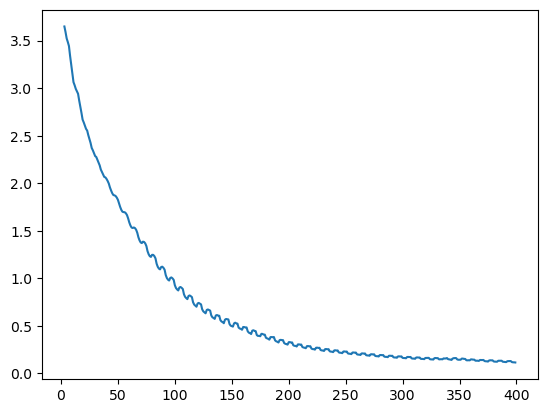

In [44]:
# 학습 결과 시각화: 손실

import matplotlib.pyplot as plt
import pandas as pd

plt.plot(pd.Series(losses_3).rolling(4).mean())

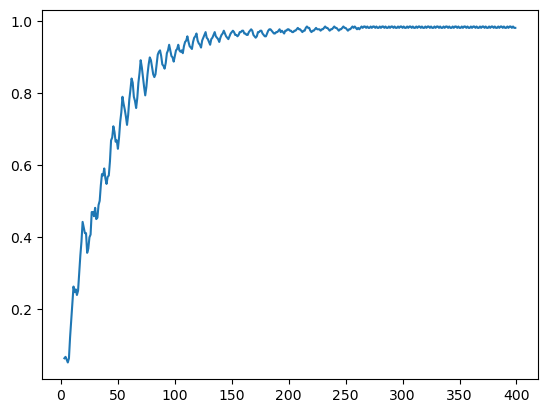

In [45]:
# 학습 결과 시각화: 정확도

plt.plot(pd.Series(accuracy_3).rolling(4).mean())

In [46]:
start = np.random.randint(0, len(valid_unit_list)-150)
seed_list = valid_unit_list[start:start+20]

current_string = [string for string in seed_list]
print(current_string)

[',', '구천', '칠백', '구', ',', '구천', '칠백', '십', ',', '구천', '칠백', '십', '일', ',', '구천', '칠백', '십', '이', ',', '구천']


In [47]:
current_string = [string2int_unit[string] for string in seed_list]
print(current_string)

[28, 21, 34, 20, 28, 21, 34, 4, 28, 21, 34, 4, 11, 28, 21, 34, 4, 26, 28, 21]


In [48]:
model2_unit.eval()

for i in range(20):
    x = torch.tensor(current_string, dtype=torch.long).to(device).reshape(1,-1)
    output = model2_unit(x)
    predicted = torch.argmax(output[:,-1,:], dim=1)
    current_string.append(predicted.item())
    
print(' '.join(seed_list))

, 구천 칠백 구 , 구천 칠백 십 , 구천 칠백 십 일 , 구천 칠백 십 이 , 구천


In [49]:
print(' '.join(int2string_unit[x] for x in current_string))

, 구천 칠백 구 , 구천 칠백 십 , 구천 칠백 십 일 , 구천 칠백 십 이 , 구천 육십 , 사천 팔백 육십 삼 , 육천 팔백 육십 사 , 육천 팔백 육십 오 , 육천 팔백 육십


#### 3.2.2 PyTorch의 nn.LSTM를 이용한 모델을 통한 음절 단위 학습 및 시험

In [50]:
nx = nq = len(vocab_char)
model2_char = LSTMModel(nx).to(device)
model2_char.train()

LSTMModel(
  (W_xh): Embedding(13, 64)
  (rnn): LSTM(64, 64, num_layers=2, batch_first=True)
  (W_hq): Linear(in_features=64, out_features=13, bias=True)
  (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)

In [51]:
data2_char = DataLoaderModel(train_char_list, string2int_char, tbptt_length=10)
x, y = next(data2_char)
y_hat = model2_char(x)
print(y.size(), y_hat.size())

torch.Size([64, 10]) torch.Size([64, 10, 13])


In [52]:
# 손실 함수 및 최적화 함수 구현
lr = 1e-3

# 음절 단위 모델을 위한 옵티마이저
optimizer2_char = torch.optim.Adam(model2_char.parameters(), lr=lr)


def loss_func(output, target):
    return F.cross_entropy(output.permute(0,2,1), target)  # 클래스 위치 변경

In [53]:
#평가 지표 저장 공간 준비
losses_4=[]
accuracy_4=[]

#학습
batch_size = 64
n_epochs   = 50

for epoch in range(1, n_epochs+1):
    # 여기서 음절단위 파라미터들로 넘겨줌
    data = DataLoaderModel(train_char_list, string2int_char, tbptt_length=70, batch_size=batch_size)
    
    for x, y in data:
        y_hat = model2_char(x)
        loss = loss_func(y_hat, y)
        loss.backward()
        optimizer2_char.step()
        optimizer2_char.zero_grad()
        
        predicted = torch.argmax(y_hat[:,-1,:], dim=1) # max_indices를 예측값으로 저장
        
        correct = (predicted==y[:,-1]).sum().item()
        
        losses_4.append(loss.item())
        accuracy_4.append(correct / batch_size)
        
    print('Epoch: {:2}/{}  |  Loss: {:.4f}  |  Accuracy: {:.4f}'.format(epoch, n_epochs, np.mean(losses_4[-3:]), np.mean(accuracy_4[-3:])))

Epoch:  1/50  |  Loss: 1.9669  |  Accuracy: 0.4583
Epoch:  2/50  |  Loss: 1.6577  |  Accuracy: 0.4688
Epoch:  3/50  |  Loss: 1.4588  |  Accuracy: 0.4740
Epoch:  4/50  |  Loss: 1.3323  |  Accuracy: 0.4844
Epoch:  5/50  |  Loss: 1.2540  |  Accuracy: 0.5052
Epoch:  6/50  |  Loss: 1.1921  |  Accuracy: 0.5625
Epoch:  7/50  |  Loss: 1.1320  |  Accuracy: 0.5885
Epoch:  8/50  |  Loss: 1.0683  |  Accuracy: 0.6250
Epoch:  9/50  |  Loss: 1.0032  |  Accuracy: 0.6615
Epoch: 10/50  |  Loss: 0.9400  |  Accuracy: 0.6823
Epoch: 11/50  |  Loss: 0.8795  |  Accuracy: 0.7240
Epoch: 12/50  |  Loss: 0.8209  |  Accuracy: 0.7708
Epoch: 13/50  |  Loss: 0.7630  |  Accuracy: 0.8125
Epoch: 14/50  |  Loss: 0.6977  |  Accuracy: 0.8594
Epoch: 15/50  |  Loss: 0.6433  |  Accuracy: 0.8854
Epoch: 16/50  |  Loss: 0.5975  |  Accuracy: 0.9323
Epoch: 17/50  |  Loss: 0.5658  |  Accuracy: 0.9688
Epoch: 18/50  |  Loss: 0.5174  |  Accuracy: 0.9740
Epoch: 19/50  |  Loss: 0.4796  |  Accuracy: 0.9688
Epoch: 20/50  |  Loss: 0.4478  

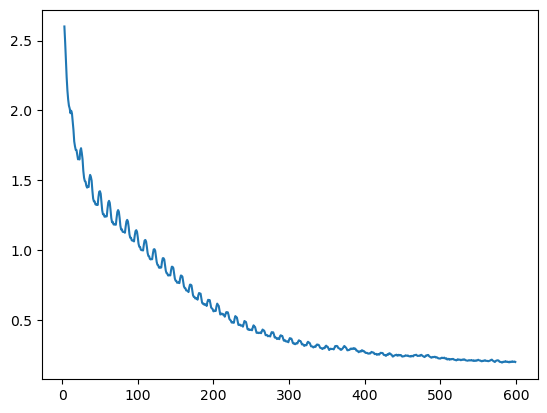

In [54]:
# 학습 결과 시각화: 손실

import matplotlib.pyplot as plt
import pandas as pd

plt.plot(pd.Series(losses_4).rolling(4).mean())

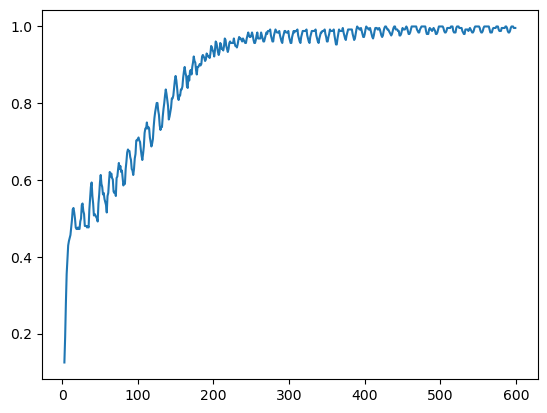

In [55]:
# 학습 결과 시각화: 정확도

plt.plot(pd.Series(accuracy_4).rolling(4).mean())

In [56]:
start = np.random.randint(0, len(valid_char_list)-150)
seed_list = valid_char_list[start:start+20]

current_string = [string for string in seed_list]
print(current_string)

[',', '팔', '천', '백', '오', '십', ',', '팔', '천', '백', '오', '십', '일', ',', '팔', '천', '백', '오', '십', '이']


In [57]:
current_string = [string2int_char[string] for string in seed_list]
print(current_string)

[8, 1, 10, 4, 6, 2, 8, 1, 10, 4, 6, 2, 9, 8, 1, 10, 4, 6, 2, 7]


In [58]:
model2_char.eval()

for i in range(20):
    x = torch.tensor(current_string, dtype=torch.long).to(device).reshape(1,-1)
    output = model2_char(x)
    predicted = torch.argmax(output[:,-1,:], dim=1)
    current_string.append(predicted.item())
    
print(' '.join(seed_list))

, 팔 천 백 오 십 , 팔 천 백 오 십 일 , 팔 천 백 오 십 이


In [59]:
print(' '.join(int2string_char[x] for x in current_string))

, 팔 천 백 오 십 , 팔 천 백 오 십 일 , 팔 천 백 오 십 이 , 팔 천 백 오 십 삼 , 팔 백 오 십 사 , 팔 백 오 십 오 ,


## 4. 실험 결과 및 분석
<hr>

### 4.1 학습 과정 시각화 분석

In [60]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False 

histories = {
    '직접 구현 (어절)': {'loss': losses_1, 'accuracy': accuracy_1},
    '직접 구현 (음절)': {'loss': losses_2, 'accuracy': accuracy_2},
    'nn.LSTM (어절)': {'loss': losses_3, 'accuracy': accuracy_3},
    'nn.LSTM (음절)': {'loss': losses_4, 'accuracy': accuracy_4}
}


1) 어절 단위 모델 학습 과정 비교

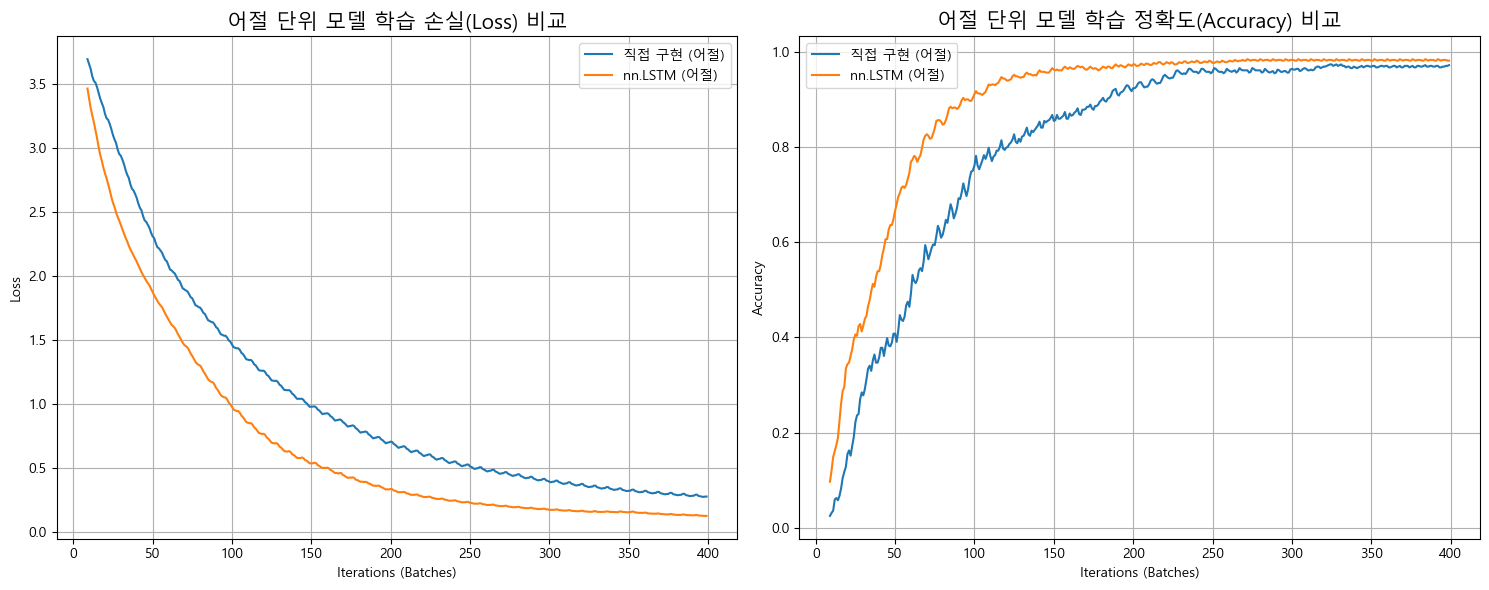

In [61]:
# --- 1. 어절 단위 모델 학습 과정 시각화 ---
unit_histories = {name: data for name, data in histories.items() if '어절' in name}
plt.figure(figsize=(15, 6))

# 손실(Loss) 그래프
plt.subplot(1, 2, 1)
for name, history in unit_histories.items():
    plt.plot(pd.Series(history['loss']).rolling(10).mean(), label=name)
plt.title('어절 단위 모델 학습 손실(Loss) 비교', fontsize=15)
plt.xlabel('Iterations (Batches)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 정확도(Accuracy) 그래프
plt.subplot(1, 2, 2)
for name, history in unit_histories.items():
    plt.plot(pd.Series(history['accuracy']).rolling(10).mean(), label=name)
plt.title('어절 단위 모델 학습 정확도(Accuracy) 비교', fontsize=15)
plt.xlabel('Iterations (Batches)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

2) 음절 단위 모델 학습 과정 비교

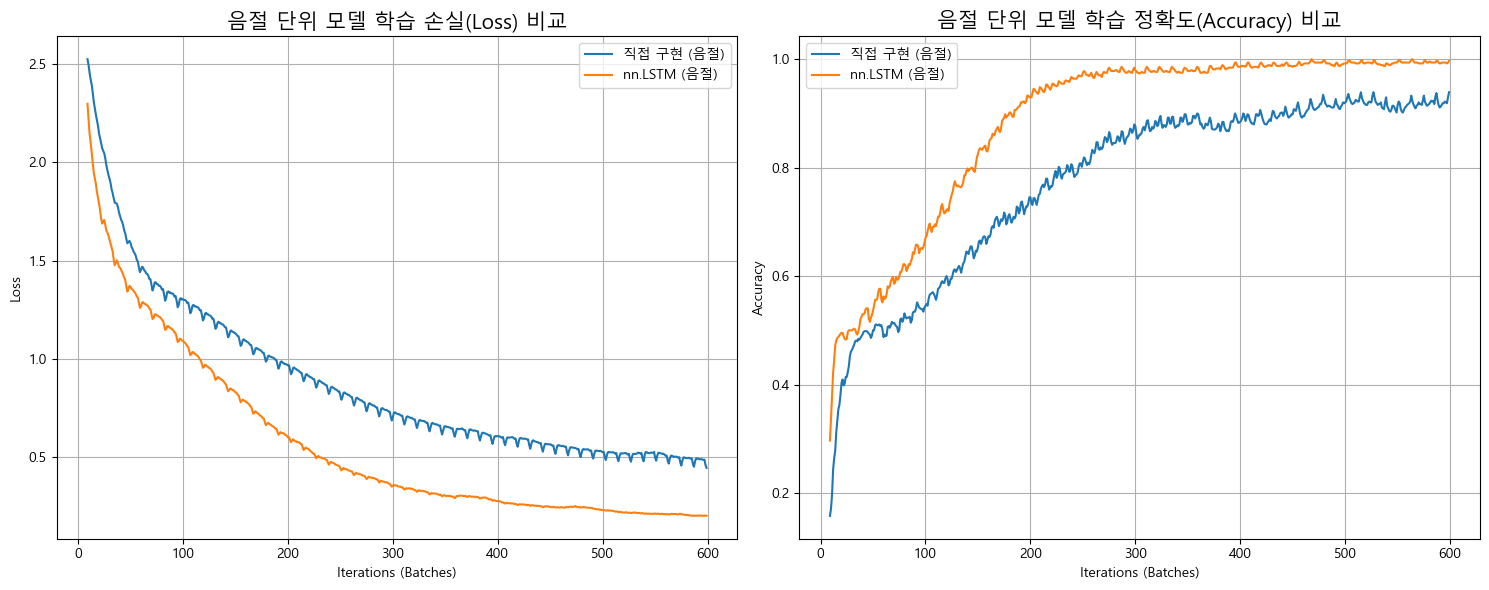

In [62]:
# --- 2. 음절 단위 모델 학습 과정 시각화 ---
char_histories = {name: data for name, data in histories.items() if '음절' in name}
plt.figure(figsize=(15, 6))

# 손실(Loss) 그래프
plt.subplot(1, 2, 1)
for name, history in char_histories.items():
    plt.plot(pd.Series(history['loss']).rolling(10).mean(), label=name)
plt.title('음절 단위 모델 학습 손실(Loss) 비교', fontsize=15)
plt.xlabel('Iterations (Batches)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 정확도(Accuracy) 그래프
plt.subplot(1, 2, 2)
for name, history in char_histories.items():
    plt.plot(pd.Series(history['accuracy']).rolling(10).mean(), label=name)
plt.title('음절 단위 모델 학습 정확도(Accuracy) 비교', fontsize=15)
plt.xlabel('Iterations (Batches)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 4.2 시험 성능 정량적 비교

In [63]:
def evaluate_model(model, data_loader, loss_func):
    model.eval()
    total_loss = 0
    correct_predictions = 0
    total_samples = 0
    num_batches = 0
    
    with torch.no_grad():
        data_loader.index = 0
        for x, y in data_loader:
            y_hat = model(x)
            loss = loss_func(y_hat, y)
            
            predicted = torch.argmax(y_hat, dim=2)
            correct_predictions += (predicted == y).sum().item()
            total_samples += y.numel()
            total_loss += loss.item()
            num_batches += 1

    avg_loss = total_loss / num_batches
    avg_accuracy = correct_predictions / total_samples
    
    return avg_loss, avg_accuracy


valid_loader_unit = DataLoaderModel(valid_unit_list, string2int_unit, batch_size=64)
valid_loader_char = DataLoaderModel(valid_char_list, string2int_char, batch_size=64)


eval_res = {}
eval_res['직접 구현 (어절)'] = evaluate_model(model1_unit, valid_loader_unit, loss_func)
eval_res['직접 구현 (음절)'] = evaluate_model(model1_char, valid_loader_char, loss_func)
eval_res['nn.LSTM (어절)'] = evaluate_model(model2_unit, valid_loader_unit, loss_func)
eval_res['nn.LSTM (음절)'] = evaluate_model(model2_char, valid_loader_char, loss_func)

df_results = pd.DataFrame(eval_res, index=['Test Loss', 'Test Accuracy']).T


styled_df = df_results.style.format({
    'Test Loss': '{:.4f}',
    'Test Accuracy': '{:.4%}'
}).background_gradient(
    cmap='Reds', subset=['Test Loss'] 
).background_gradient(
    cmap='Greens', subset=['Test Accuracy'] 
)
styled_df


,Test Loss,Test Accuracy
직접 구현 (어절),30.3155,3.5045%
직접 구현 (음절),34.2520,10.5753%
nn.LSTM (어절),3.3584,31.6518%
nn.LSTM (음절),1.9085,45.2841%


### 4.3 실제 예측 결과 정성적 비교

In [77]:
def safe_int2string(idx, int2string):
    return int2string.get(idx, 'UNK')

# 생성 함수
def generate(model, current_string, int2string, steps=20):
    cur = current_string.copy()
    gen = [safe_int2string(i, int2string) for i in cur]
    for _ in range(steps):
        x = torch.tensor(cur, dtype=torch.long).to(device).reshape(1, -1)
        output = model(x)
        predicted = torch.argmax(output[:, -1, :], dim=1)
        predicted_word = safe_int2string(predicted.item(), int2string)
        gen.append(predicted_word)
        cur.append(predicted.item())
    return gen

# 시드 리스트 정수 인덱스로 변환
cur1_unit = [string2int_unit[s] for s in seed_list]  # 어절
cur1_char = [string2int_char[s] for s in seed_list]  # 음절
cur2_unit = cur1_unit.copy()
cur2_char = cur1_char.copy()

# 생성
gen1_unit = generate(model1_unit, cur1_unit, int2string_unit)
gen1_char = generate(model1_char, cur1_char, int2string_char)
gen2_unit = generate(model2_unit, cur2_unit, int2string_unit)
gen2_char = generate(model2_char, cur2_char, int2string_char)

df = pd.DataFrame({
    "Step": list(range(len(gen1_unit))),
    "직접 구현 (어절)": gen1_unit,
    "직접 구현 (음절)": gen1_char,
    "nn.LSTM (어절)": gen2_unit,
    "nn.LSTM (음절)": gen2_char
})

display(df)

,Step,직접 구현 (어절),직접 구현 (음절),nn.LSTM (어절),nn.LSTM (음절)
0,0,",",",",",",","
1,1,팔,팔,팔,팔
2,2,천,천,천,천
3,3,백,백,백,백
4,4,오,오,오,오
5,5,십,십,십,십
6,6,",",",",",",","
7,7,팔,팔,팔,팔
8,8,천,천,천,천
9,9,백,백,백,백


## 5. 분석 및 결론
<hr>

### 5.1 시험성능 정량적 비교분석
| 구현 방식        | 데이터 단위 | Test Loss | Test Accuracy | 
|-----------------|------------|-----------|---------------|
| 직접 구현        | 어절       | 30.3155   | 3.50%         | 
| 직접 구현        | 음절       | 34.2520   | 10.57%        | 
| nn.LSTM          | 어절       | 3.3584    | 31.65%        |
| nn.LSTM          | 음절       | 1.9085    | 45.28%        | 
- nn.LSTM 모델이 직접 구현 모델보다 전반적으로 높은 성능을 기록함.  
- 모든 모델에서 **음절 단위**가 어절 단위보다 높은 정확도를 보임.  
- nn.LSTM + 음절 단위 조합이 가장 안정적이고 높은 성능 달성함

### 5.2 시험성능 정성적 비교분석
| Step | 직접 구현 (어절) | 직접 구현 (음절) | nn.LSTM (어절) | nn.LSTM (음절) |
|------|-----------------|-----------------|----------------|----------------|
| 21   | 칠천            | 오              | 사천           | 팔             |
| 22   | 육백            | 천              | 백             | 천             |
| 23   | 십              | 백              | 십             | 백             |
| 24   | 삼              | 이              | 삼             | 오             |
| 25   | 육              | 십              | ,              | 십             |
| 26   | ,               | 오              | 사천           | 삼             |
| 27   | 칠천            | ,               | 백             | ,              |
| 28   | 육백            | 오              | 십             | 팔             |
| 29   | 십              | 천              | 사             | 백             |
| 30   | 칠              | 삼              | ,              | 오             |
| 31   | ,               | 백              | 사천           | 십             |
| 32   | 칠천            | 이              | 백             | 사             |
| 33   | 육백            | 십              | 십             | ,              |
| 34   | 십              | 오              | 오             | 팔             |
| 35   | 팔              | ,               | ,              | 백             |
| 36   | ,               | 오              | 사천           | 오             |
| 37   | 칠천            | 천              | 백             | 십             |
| 38   | 육백            | 삼              | 십             | 오             |
| 39   | 십              | 백              | 육             | ,              |
- nn.LSTM 모델은 일부 수치를 정확히 예측했으며, 직접 구현 모델은 대부분 잘못된 예측을 기록함.  
- 특히 큰 수나 연속된 단어 조합에서 직접 구현 모델의 예측 정확도 낮음.  

### 5.3 결론

1. **구현 방식 비교**
   - nn.LSTM 모델이 직접 구현한 모델보다 전체적으로 높은 성능을 기록함.  
   - 학습 과정에서 더 안정적으로 숫자 패턴을 학습할 수 있었던 것으로 보임.

2. **데이터 단위 비교**
   - 모든 모델에서 **음절 단위**가 어절 단위보다 높은 정확도를 보임.  
   - 음절 단위는 숫자를 의미 단위로 나누어(`십-팔`, `이-십-일`) 학습하므로, 모델이 패턴을 이해하고 예측하기 더 쉬웠던 것으로 보임.
 
3. **과적합 관찰**
   - 훈련 데이터에서는 높은 성능을 보였으나, 시험 데이터에서는 낮은 정확도와 높은 손실을 기록 → **과적합 발생**  
   - 학습 과정에서 DataLoader를 매 epoch마다 새로 만들고, **데이터가 섞이지 않은 상태**로 학습했기 때문에 모델이 특정 데이터 순서에 과도하게 맞춰진 것으로 판단됨.

**종합 결론**  
- **nn.LSTM + 음절 단위** 조합이 가장 안정적이며 높은 성능을 보임.  
- 직접 구현 모델은 복잡한 패턴을 학습하는 데 한계가 있으며, 과적합을 막기 위해 데이터 처리와 학습 방법 개선이 필요함.
